# Model Project

Import and set magics:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import modelproject

> Part 1: A consumer with two nests

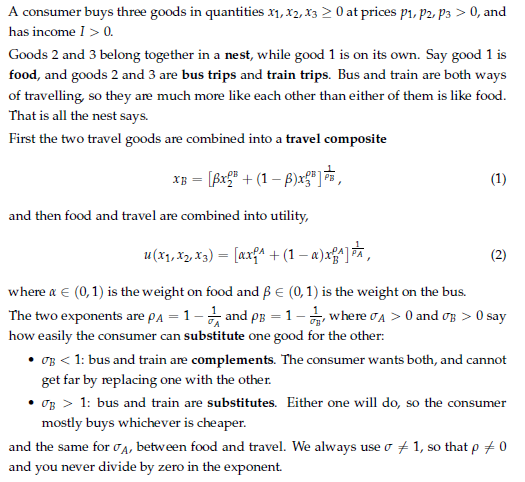

> 1.1: The problem in nested budget shares

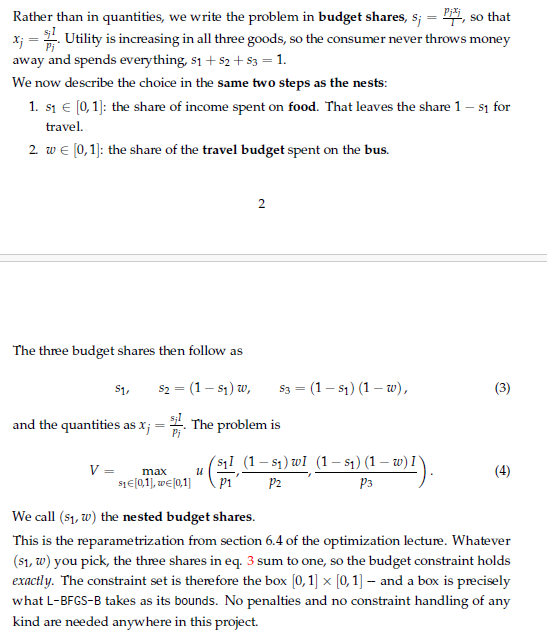

> 1.2: Calibration

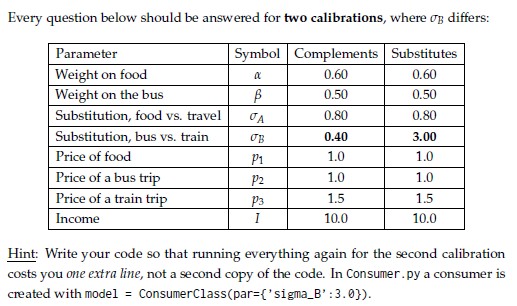

> 1.3: How to tell if the answer is right

In [2]:
# There is no formula for the solution of this model, so you cannot look the answer 
# up. Two cheap checks:
# 1. Is the answer possible? All three shares should be strictly between 0 and 1 and
# sum to one, and all three quantities should be positive.
# 2. Do two different methods agree? In section 2 you solve the same problem twice.

> Part 2: Solving the model numerically

> 2.1: A two-dimensional grid search

In [3]:
# The idea is the one from the optimization lecture: lay a grid over everything the
# consumer can afford, compute utility in every point, and keep the best one. Nothing
# clever happens -- and that is the point.
# 1. Make a grid of N values of s1 and N values of w, both from 0 to 1, compute utility
# in every combination, and keep the best point. Implement it as solve_grid(). 
# Report both (s1, w) and the three budget shares it implies.
# Hint: np.meshgrid(s1_vec,w_vec,indexing=’ij’) builds the grid, and np.argmax
# togetherwith np.unravel_index finds the best point. Note that there is nothing
# to mask out and no np.nan anywhere: every point of the square is a possible
# choice.

In [4]:
# 2. Plot utility over the nested shares in 3D(ax = fig.add_subplot(1,2,1,projection=’3d’) 
# and ax.plot_surface) and as a contour plot (ax.contourf), with the solution marked.

In [5]:
# Try N = 50, 100, 500 and 1000. How much does the answer move when you
# add points, and how many evaluations of u does it cost? Does it improve
# smoothly?

In [6]:
# 4. Compare the two calibrations. Where is the surface steep, and where is it flat?
# Which of the two would you expect to be harder for an optimizer?

> 2.2: L-BFGS-B

In [ ]:
# L-BFGS-B is the workhorse for smooth problems with several variables and simple
# bounds. The B stands for bounds: it takes a box around each variable, but it does not
# take general constraints. Because we wrote the problem in nested budget shares, a
# box is all we need -- the whole of solve() is 
# minimize(self.objective,s0,method=’L-BFGS-B’,bounds=((0,1),(0,1)))
# and objective() is just −u. There is nothing else to arrange.
# 1. Solve the problem this way and implement it as solve(). Compare the solution,
# the number of function evaluations and the running time with the grid
# search. Do the two methods agree?

In [7]:
# 2. Record the convergence pathwith the callback argument of optimize.minimize, 
# and draw it on top of the contour plot from section 2.1. Then plot how far each
# iteration is from the point the solver ends at, against the iteration number, on a
# log scale. Where does the method make fast progress, and where is it slow?
# Hint: optimize.minimize calls the function you give it as callback once per
# iteration, with the current point as its only argument. That is the only way to
# see the path: the result object holds the point the solver stopped at, and nothing
# about how it got there. Note that an iteration is not a function evaluation --
# the solver computes u several times per iteration, for the gradient and for the
# line search, and the callback fires only for the steps it actually takes. It is not
# called for the starting point either, so put s0 in the list yourself before you call
# the solver. Use callback=lambda sk: path.append(sk.copy()). The .copy()
# is defensive: if the solver reused one array and overwrote it, you would get the
# same point repeated.

In [8]:
# Solve from at least six different starting points, including the middle (1/2 , 1/2)
# and all four corners of the square. Do you always get the same answer? Does
# the number of iterations change?
# One corner fails in one of the two calibrations, and reports success = True
# while doing so. Find it, and describe what happens there.

In [ ]:
# Vary the settings below -- they all go in options={...} -- and report the two
# shares, the utility reached and the number of function evaluations for each of
# them in one table:
#(a) ftol (stop when the objective stops changing): 10−4, 10−8, 10−12, 10−16
#(b) gtol (stop when the gradient is small): 10−2, 10−5, 10−8, 10−12

In [9]:
# Which settings would you use? Note that you can rank them without knowing
#the true answer: we are maximizing, so a higher utility is a better answer.
#Why is a tighter tolerance not always a better answer?

> Part 3: Relative prices and demand

In [10]:
# We now use the model. Train tickets get more expensive, and we ask what the consumer does.
# 1. Solve the model for p3 from 0.5 to 3.0, holding p1, p2 and I fixed, and plot
#the three budget shares and the three quantities. Do it for both calibrations,
#ideally in the same figure.

In [11]:
# 2. In which calibration does a higher p3 raise the budget share of the train, and in
#which does it lower it?

In [ ]:
# 3. What happens to the number of bus trips when train tickets get more expensive?
#Describe how the two calibrations differ.

In [12]:
# 4. How much does the price of a train ticket change the demand for food? Compare
#with the effect on bus trips.

> Part 4: Lump-sum taxes and product taxes

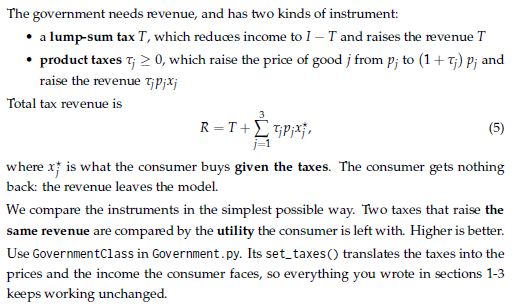

In [13]:
# 1. Implement tax_revenue() (eq. 5).

In [14]:
# 2. Consider five product taxes: on food only, on the bus only, on the train only,
#the same rate on bus and train, and the same rate on all three goods. For each
#of them, plot the revenue as a function of the tax rate for rates from 0 to 3, one
#panel per calibration.

In [15]:
# 3. Which of the curves have a top, and which just keep rising? Find the revenuemaximizing
#rate and the largest possible revenue where there is a top. In particular:
#what is the most that a tax on train tickets alone can ever raise in the
#substitutes calibration?
#Hint: Use a grid over the tax rate and pick the best point, exactly as in section
#2.1. Read off your figure from question 2 how far out the grid has to go.

In [16]:
# 4. Plot the consumer’s utility against the revenue raised, for all five product taxes
#and for the lump-sum tax, one panel per calibration. Which instrument is the
#cheapest way to raise a given revenue, and does the ranking depend on the
#calibration?

In [17]:
# 5. Let the government need R = 0.20, i.e. 2 percent of income. Use a root-finder
#to find the tax rate that raises exactly that for each instrument, and report the
#rate and the resulting utility in one table per calibration. Rank the instruments,
#and comment in particular on the tax on train tickets.
#Hint: optimize.root_scalar(f,bracket=[...],method=’brentq’) where f is
#the revenue minus the target.

> Part 5: Extension

In [18]:
# Extend the model in one direction of your own choice, solve it, and describe the
#results.
#Note: This is intended as an open question, and we encourage you to be creative.